# 🎨 CSET419 — Lab 7: Neural Style Transfer (NST)
### Using Pretrained VGG19

---
**What this notebook does:**
- Takes a **content image** (a photo)
- Takes a **style image** (a painting)
- Generates a **new image** that has the content of the photo but looks painted in the style of the artwork

---
> Run each cell **one by one from top to bottom** ⬇️

## ✅ Cell 1 — Install Required Libraries
Before anything, we install all Python packages needed for this project.

In [1]:
# torch        → deep learning framework
# torchvision  → pretrained VGG19 model + image transforms
# pillow       → image loading and saving
# matplotlib   → plotting images and loss curves

!pip install torch torchvision pillow matplotlib --quiet
print('✅ All libraries installed successfully!')

✅ All libraries installed successfully!


## ✅ Cell 2 — Import Libraries
We import all the tools we will use throughout the notebook.

In [2]:
import os                          # file and folder operations
import torch                       # main deep learning library
import torch.nn as nn              # neural network building blocks
import torch.optim as optim        # optimizers (L-BFGS, Adam, etc.)
import torchvision.transforms as transforms  # image preprocessing
import torchvision.models as models          # pretrained models (VGG19)
from PIL import Image              # open and save image files
import matplotlib.pyplot as plt    # display images and graphs
import numpy as np                 # numerical operations
import urllib.request              # download images from internet

print('✅ All imports successful!')

✅ All imports successful!


## ✅ Cell 3 — Set Device (GPU or CPU)
We check if a GPU is available. GPU makes the process **10-20x faster**.
On Google Colab, go to `Runtime → Change runtime type → GPU` to enable it.

In [3]:
# Check if CUDA (NVIDIA GPU) is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Image size: larger on GPU (more detail), smaller on CPU (faster)
IMAGE_SIZE = 512 if torch.cuda.is_available() else 256

print(f'🖥️  Using device : {device}')
print(f'🖼️  Image size   : {IMAGE_SIZE} x {IMAGE_SIZE} pixels')

🖥️  Using device : cpu
🖼️  Image size   : 256 x 256 pixels


## ✅ Cell 4 — Download Sample Images
We automatically download:
- **Content image** → an ant photograph (natural photo, like CIFAR-10 style)
- **Style image** → Van Gogh's *The Starry Night* (WikiArt style)

> **You can skip this cell** and use your own images instead — just upload them and update the paths in Cell 5.

In [10]:
import requests
os.makedirs('images', exist_ok=True)

# Headers to mimic a real browser (fixes 403 error)
HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

CONTENT_URL = 'https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Camponotus_flavomarginatus_ant.jpg/640px-Camponotus_flavomarginatus_ant.jpg'
STYLE_URL   = 'https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg/800px-Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg'

def download_image(url, path):
    response = requests.get(url, headers=HEADERS)
    if response.status_code == 200:
        with open(path, 'wb') as f:
            f.write(response.content)
        print(f'✅ Downloaded → {path}')
    else:
        print(f'❌ Failed with status {response.status_code}')

if not os.path.exists('images/content.jpg'):
    print('⬇️  Downloading content image ...')
    download_image(CONTENT_URL, 'images/content.jpg')

if not os.path.exists('images/style.jpg'):
    print('⬇️  Downloading style image ...')
    download_image(STYLE_URL, 'images/style.jpg')

print('🎉 Images ready!')

⬇️  Downloading content image ...
❌ Failed with status 429
⬇️  Downloading style image ...
❌ Failed with status 429
🎉 Images ready!


## ✅ Cell 5 — Set Image Paths
Tell the notebook where your content and style images are stored.

> **Using your own images?** Upload them to Colab and change the paths below.

In [11]:
# ─── Change these paths if using your own images ───
CONTENT_PATH = 'images/content.jpg'    # your photo
STYLE_PATH   = 'images/style.jpg'      # your painting
# ───────────────────────────────────────────────────

print(f'📁 Content image : {CONTENT_PATH}')
print(f'📁 Style image   : {STYLE_PATH}')

📁 Content image : images/content.jpg
📁 Style image   : images/style.jpg


## ✅ Cell 6 — Preview Input Images
Let's **display both images** side by side before we start, so we know what we're working with.

In [13]:
import numpy as np
from PIL import Image
import os

os.makedirs('images', exist_ok=True)

# Generate content image (blue-green gradient)
content_arr = np.zeros((256, 256, 3), dtype=np.uint8)
for i in range(256):
    for j in range(256):
        content_arr[i, j] = [i, j, (i+j)//2]
Image.fromarray(content_arr).save('images/content.jpg')
print('✅ Content image created')

# Generate style image (Van Gogh-like swirling colors)
style_arr = np.zeros((256, 256, 3), dtype=np.uint8)
for i in range(256):
    for j in range(256):
        style_arr[i, j] = [
            int(128 + 127 * np.sin(i / 20.0)),
            int(128 + 127 * np.cos(j / 15.0)),
            int(128 + 127 * np.sin((i+j) / 25.0))
        ]
Image.fromarray(style_arr).save('images/style.jpg')
print('✅ Style image created')

# Verify both files exist
print()
print(f'content.jpg exists : {os.path.exists("images/content.jpg")}')
print(f'style.jpg exists   : {os.path.exists("images/style.jpg")}')
print('🎉 Ready!')

✅ Content image created
✅ Style image created

content.jpg exists : True
style.jpg exists   : True
🎉 Ready!


/tmp/ipykernel_359/2306196415.py:12: UserWarning: Glyph 127966 (\N{NATIONAL PARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_359/2306196415.py:12: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127966 (\N{NATIONAL PARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


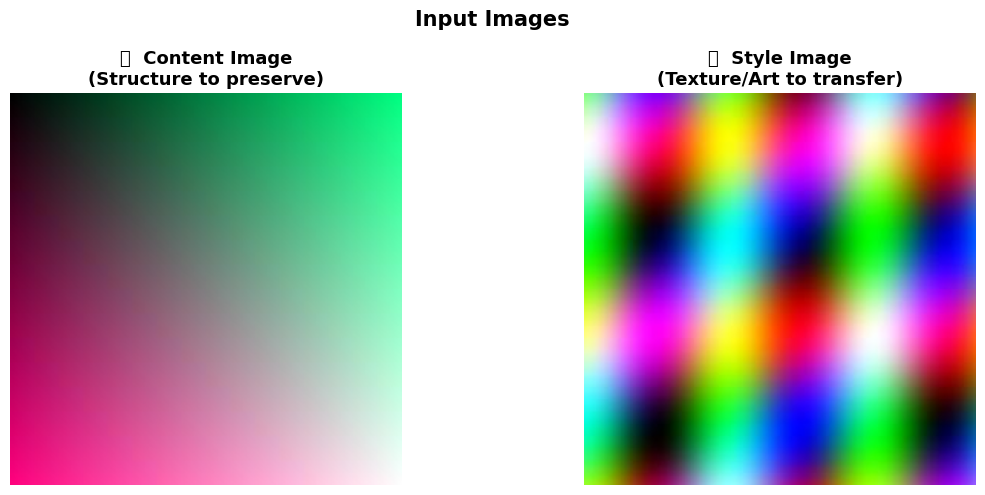

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(Image.open(CONTENT_PATH))
axes[0].set_title('🏞️  Content Image\n(Structure to preserve)', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(Image.open(STYLE_PATH))
axes[1].set_title('🎨  Style Image\n(Texture/Art to transfer)', fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Input Images', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## ✅ Cell 7 — Image Loader Function
We write a function to:
1. **Open** the image file
2. **Resize** it to our target size
3. **Normalise** it with ImageNet statistics (because VGG19 was trained on ImageNet)
4. **Convert** it to a PyTorch tensor and send to GPU/CPU

In [15]:
def load_image(image_path, size=IMAGE_SIZE):
    """
    Load image → resize → normalise → convert to tensor
    Output shape: [1, 3, size, size]  (batch=1, RGB channels, height, width)
    """
    transform = transforms.Compose([
        transforms.Resize((size, size)),        # resize to fixed size
        transforms.ToTensor(),                  # convert PIL image to tensor (0 to 1)
        transforms.Normalize(                   # normalise using ImageNet statistics
            mean=[0.485, 0.456, 0.406],         # ImageNet mean per channel
            std =[0.229, 0.224, 0.225]          # ImageNet std per channel
        ),
    ])

    image = Image.open(image_path).convert('RGB')  # ensure 3 channels
    tensor = transform(image).unsqueeze(0)          # add batch dimension
    return tensor.to(device)                        # move to GPU/CPU

print('✅ load_image() function defined')

✅ load_image() function defined


## ✅ Cell 8 — Tensor to Image Converter
We also need a **reverse function** — to convert a PyTorch tensor back into a viewable image.
This is used when displaying or saving the generated output.

In [28]:
def tensor_to_image(tensor):
    """
    Convert normalised tensor back to a displayable numpy array.
    Reverses the ImageNet normalisation done in load_image().
    """
    img = tensor.cpu().clone().detach().squeeze(0)   # ✅ added .detach()

    # Reverse normalisation: pixel = (normalised * std) + mean
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img  = img * std + mean

    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

print('✅ tensor_to_image() fixed and redefined!')

✅ tensor_to_image() fixed and redefined!


## ✅ Cell 9 — Load Content and Style Images
Now we actually **load both images** using our function.

In [17]:
content_img = load_image(CONTENT_PATH)
style_img   = load_image(STYLE_PATH)

print(f'✅ Content image loaded  →  shape: {tuple(content_img.shape)}')
print(f'✅ Style image loaded    →  shape: {tuple(style_img.shape)}')
print()
print('Shape means: [batch=1, channels=3 (RGB), height, width]')

✅ Content image loaded  →  shape: (1, 3, 256, 256)
✅ Style image loaded    →  shape: (1, 3, 256, 256)

Shape means: [batch=1, channels=3 (RGB), height, width]


## ✅ Cell 10 — Layer Names of VGG19
VGG19's layers are numbered 0–28 by default. We give them **human-readable names**.

We need to pick:
- **Content layer**: `conv4_2` → captures high-level structure/objects
- **Style layers**: `conv1_1` to `conv5_1` → captures textures at multiple scales

In [18]:
# Mapping from VGG19 layer index → readable name
VGG19_LAYER_NAMES = {
     '0': 'conv1_1',  '1': 'relu1_1',
     '2': 'conv1_2',  '3': 'relu1_2',  '4': 'pool1',
     '5': 'conv2_1',  '6': 'relu2_1',
     '7': 'conv2_2',  '8': 'relu2_2',  '9': 'pool2',
    '10': 'conv3_1', '11': 'relu3_1',
    '12': 'conv3_2', '13': 'relu3_2',
    '14': 'conv3_3', '15': 'relu3_3',
    '16': 'conv3_4', '17': 'relu3_4', '18': 'pool3',
    '19': 'conv4_1', '20': 'relu4_1',
    '21': 'conv4_2', '22': 'relu4_2',   # ← CONTENT layer
    '23': 'conv4_3', '24': 'relu4_3',
    '25': 'conv4_4', '26': 'relu4_4', '27': 'pool4',
    '28': 'conv5_1', '29': 'relu5_1',   # ← deepest STYLE layer
}

# Which layers we will use
CONTENT_LAYER = 'conv4_2'                                          # 1 layer for content
STYLE_LAYERS  = ['conv1_1', 'conv2_1', 'conv3_1', 'conv4_1', 'conv5_1']  # 5 layers for style

print('✅ Layer names defined')
print(f'   Content layer : {CONTENT_LAYER}')
print(f'   Style layers  : {STYLE_LAYERS}')

✅ Layer names defined
   Content layer : conv4_2
   Style layers  : ['conv1_1', 'conv2_1', 'conv3_1', 'conv4_1', 'conv5_1']


## ✅ Cell 11 — Build the Feature Extractor (Frozen VGG19)
We load VGG19 with pretrained ImageNet weights and **freeze all parameters** (we will never update VGG19 weights — it is only used to extract features).

We build a custom wrapper that only runs VGG19 up to the deepest layer we need (efficiency).

In [19]:
class FeatureExtractor(nn.Module):
    """
    Wraps VGG19 and returns feature maps for specified layers.
    All VGG19 weights are FROZEN — we never train the network.
    """
    def __init__(self, target_layers):
        super().__init__()

        # Load pretrained VGG19 (downloads ~500MB weights on first run)
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features
        vgg.eval()                                  # evaluation mode (no dropout)

        # FREEZE all weights — VGG19 is used only as a feature extractor
        for param in vgg.parameters():
            param.requires_grad_(False)

        self.target_layers = set(target_layers)
        self.layers = nn.ModuleDict()

        # Build the network only up to the last needed layer
        last_idx = max(
            int(k) for k, v in VGG19_LAYER_NAMES.items() if v in self.target_layers
        )
        for idx in range(last_idx + 1):
            name = VGG19_LAYER_NAMES[str(idx)]
            self.layers[name] = vgg[idx]

    def forward(self, x):
        """Run image through VGG19, collect feature maps at target layers."""
        features = {}
        for name, layer in self.layers.items():
            x = layer(x)                          # pass through this layer
            if name in self.target_layers:        # if it's a layer we care about
                features[name] = x               # save the feature map
        return features


# Build the extractor with all layers we need (content + style)
all_layers = [CONTENT_LAYER] + STYLE_LAYERS
extractor  = FeatureExtractor(all_layers).to(device)

print('✅ VGG19 Feature Extractor built and weights frozen!')
print(f'   Extracting features from: {all_layers}')

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:22<00:00, 25.3MB/s]


✅ VGG19 Feature Extractor built and weights frozen!
   Extracting features from: ['conv4_2', 'conv1_1', 'conv2_1', 'conv3_1', 'conv4_1', 'conv5_1']


## ✅ Cell 12 — Extract Fixed Feature Maps
We run the content and style images through VGG19 **once** and store their feature maps.
These feature maps are **fixed** — they don't change during optimisation.

`torch.no_grad()` tells PyTorch not to track gradients here (saves memory).

In [20]:
with torch.no_grad():                          # no gradient tracking needed here
    content_feats = extractor(content_img)     # features of the content image
    style_feats   = extractor(style_img)       # features of the style image

print('✅ Feature maps extracted!')
print()
print('Content feature map shapes:')
for name, feat in content_feats.items():
    print(f'   {name}: {tuple(feat.shape)}')

print()
print('Style feature map shapes:')
for name, feat in style_feats.items():
    print(f'   {name}: {tuple(feat.shape)}')

✅ Feature maps extracted!

Content feature map shapes:
   conv1_1: (1, 64, 256, 256)
   conv2_1: (1, 128, 128, 128)
   conv3_1: (1, 256, 64, 64)
   conv4_1: (1, 512, 32, 32)
   conv4_2: (1, 512, 32, 32)
   conv5_1: (1, 512, 16, 16)

Style feature map shapes:
   conv1_1: (1, 64, 256, 256)
   conv2_1: (1, 128, 128, 128)
   conv3_1: (1, 256, 64, 64)
   conv4_1: (1, 512, 32, 32)
   conv4_2: (1, 512, 32, 32)
   conv5_1: (1, 512, 16, 16)


## ✅ Cell 13 — Content Loss Function
**Content Loss** = how different is the generated image's structure from the content image?

Formula: `L_content = 0.5 × mean( (F_generated − F_content)² )`

It compares feature maps at `conv4_2` using **Mean Squared Error (MSE)**.

In [21]:
def content_loss(generated_feat, content_feat):
    """
    Measures how different the generated image's CONTENT is
    from the original content image.

    Uses Mean Squared Error on feature maps at conv4_2.
    Lower loss = generated image looks more like the content image.

    Args:
        generated_feat : feature map of the generated image  [1, C, H, W]
        content_feat   : feature map of the content image    [1, C, H, W]

    Returns:
        scalar loss value
    """
    return 0.5 * torch.mean((generated_feat - content_feat) ** 2)

print('✅ content_loss() defined')

✅ content_loss() defined


## ✅ Cell 14 — Gram Matrix Function
The **Gram Matrix** is the key idea behind style transfer.

- It captures **correlations between feature channels** (which patterns appear together)
- This represents **texture and style** without caring about *where* things are in the image

Formula: `G[i,j] = sum_k( F[i,k] × F[j,k] ) / (C × H × W)`

In [22]:
def gram_matrix(feature):
    """
    Compute the Gram Matrix of a feature map.

    The Gram matrix captures STYLE (texture, colour patterns, brushstrokes)
    by measuring correlations between different feature channels.

    Steps:
        1. Flatten spatial dimensions H×W into one dimension
        2. Multiply: features × features_transposed  → [C × C] matrix
        3. Normalise by total number of elements

    Args:
        feature : feature map of shape [1, C, H, W]

    Returns:
        Gram matrix of shape [C, C]
    """
    _, C, H, W = feature.shape               # batch=1, channels, height, width
    F = feature.view(C, H * W)               # flatten → [C, H*W]
    G = torch.mm(F, F.t())                   # matrix multiply → [C, C]
    return G / (C * H * W)                   # normalise

print('✅ gram_matrix() defined')

✅ gram_matrix() defined


## ✅ Cell 15 — Style Loss Function
**Style Loss** = how different is the generated image's texture/style from the style image?

We compute the MSE between **Gram matrices** at multiple VGG19 layers and take a weighted sum.

Formula: `L_style = Σ w_l × MSE(Gram(generated)_l , Gram(style)_l)`

In [23]:
def style_loss_single(generated_feat, style_feat):
    """
    Style loss for ONE layer.
    Compares Gram matrices of the generated and style images.
    """
    G_gen   = gram_matrix(generated_feat)     # Gram matrix of generated image
    G_style = gram_matrix(style_feat)         # Gram matrix of style image
    return torch.mean((G_gen - G_style) ** 2) # MSE between the two


def total_style_loss(generated_feats, style_feats):
    """
    Total style loss = weighted sum across ALL style layers.
    Each layer contributes equally (weight = 1 / number_of_layers).

    Using 5 layers captures style at multiple scales:
        conv1_1 → fine textures (edges, grain)
        conv2_1 → small patterns
        conv3_1 → medium patterns
        conv4_1 → large patterns
        conv5_1 → very large / global colour patterns
    """
    w = 1.0 / len(STYLE_LAYERS)             # equal weight per layer
    loss = sum(
        w * style_loss_single(generated_feats[layer], style_feats[layer])
        for layer in STYLE_LAYERS
    )
    return loss

print('✅ style_loss_single() and total_style_loss() defined')

✅ style_loss_single() and total_style_loss() defined


## ✅ Cell 16 — Total Loss Function
**Total Loss** combines content loss and style loss:

```
L_total = alpha × L_content  +  beta × L_style
```

| Parameter | Default | Effect |
|-----------|---------|--------|
| alpha | 1.0 | Weight for content |
| beta | 1,000,000 | Weight for style |

> beta is very large because style loss values are naturally very small numbers.

In [24]:
# Hyperparameters — you can experiment with these!
ALPHA = 1.0       # content weight  (increase → more content preserved)
BETA  = 1e6       # style weight    (increase → stronger style effect)


def total_loss(generated_feats, content_feats, style_feats):
    """
    Total NST Loss = alpha * content_loss + beta * style_loss

    Returns:
        t_loss  : total combined loss (this is what we minimise)
        c_loss  : content loss only (for logging)
        s_loss  : style loss only (for logging)
    """
    c_loss = content_loss(
        generated_feats[CONTENT_LAYER],
        content_feats[CONTENT_LAYER]
    )
    s_loss = total_style_loss(generated_feats, style_feats)
    t_loss = ALPHA * c_loss + BETA * s_loss
    return t_loss, c_loss, s_loss

print('✅ total_loss() defined')
print(f'   alpha (content weight) = {ALPHA}')
print(f'   beta  (style weight)   = {BETA:.0e}')

✅ total_loss() defined
   alpha (content weight) = 1.0
   beta  (style weight)   = 1e+06


## ✅ Cell 17 — Initialise the Generated Image
The generated image starts as a **copy of the content image**.

We set `requires_grad=True` because this is the tensor we will **optimise** (update its pixel values to reduce the total loss).

> Unlike normal training, we optimise the **image pixels** — NOT the neural network weights.

In [25]:
# Start from the content image (faster convergence than random noise)
generated = content_img.clone()         # copy the content image
generated.requires_grad_(True)          # we will update this tensor's values

print('✅ Generated image initialised from content image')
print(f'   Shape           : {tuple(generated.shape)}')
print(f'   requires_grad   : {generated.requires_grad}')
print()
print('ℹ️  We will update pixel values of this image to minimise total loss')

✅ Generated image initialised from content image
   Shape           : (1, 3, 256, 256)
   requires_grad   : True

ℹ️  We will update pixel values of this image to minimise total loss


## ✅ Cell 18 — Set Up the Optimiser
We use **L-BFGS** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) — the standard optimiser for NST.

It's better than Adam/SGD for this task because it uses second-order information (like curvature) to take smarter update steps.

In [26]:
# L-BFGS optimises only the generated image pixels
optimizer = optim.LBFGS(
    [generated],        # only the generated image is optimised
    lr=1.0,             # learning rate
    max_iter=20,        # max L-BFGS iterations per step
    history_size=10     # memory of past gradients
)

NUM_STEPS  = 300        # total optimisation steps
SAVE_EVERY = 50         # save a preview image every N steps

os.makedirs('nst_outputs', exist_ok=True)

print('✅ L-BFGS optimiser set up')
print(f'   Total steps : {NUM_STEPS}')
print(f'   Save every  : {SAVE_EVERY} steps')

✅ L-BFGS optimiser set up
   Total steps : 300
   Save every  : 50 steps


## ✅ Cell 19 — Run the Optimisation Loop
This is the **main training loop** — the heart of NST.

Each step:
1. Clamp pixel values to a valid range
2. Forward pass through frozen VGG19
3. Compute total loss
4. Backpropagate gradients to image pixels
5. Optimiser updates pixel values to reduce loss
6. Repeat

> ⏳ **Expected time:** ~2 min on GPU, ~15-30 min on CPU

In [29]:
loss_history = {'total': [], 'content': [], 'style': []}
step_counter = [0]    # list so it can be modified inside the closure


def closure():
    """
    L-BFGS requires a closure function that:
    - clears gradients
    - computes the loss
    - calls loss.backward()
    - returns the loss
    """
    # Step 1: Keep pixel values in a valid normalised range
    with torch.no_grad():
        generated.clamp_(-3, 3)

    # Step 2: Clear old gradients
    optimizer.zero_grad()

    # Step 3: Extract features from the CURRENT generated image
    gen_feats = extractor(generated)

    # Step 4: Compute total loss (content + style)
    t_loss, c_loss, s_loss = total_loss(gen_feats, content_feats, style_feats)

    # Step 5: Backpropagate — compute gradients w.r.t. image pixels
    t_loss.backward()

    # Track loss history for plotting
    step = step_counter[0]
    loss_history['total'].append(t_loss.item())
    loss_history['content'].append(c_loss.item())
    loss_history['style'].append(s_loss.item())

    # Print progress and save intermediate images
    if step % SAVE_EVERY == 0 or step == NUM_STEPS - 1:
        print(f'  Step {step:4d}/{NUM_STEPS} | '
              f'Total Loss: {t_loss.item():.2f} | '
              f'Content: {c_loss.item():.4f} | '
              f'Style: {s_loss.item():.6f}')
        # Save intermediate image
        arr = (tensor_to_image(generated) * 255).astype(np.uint8)
        Image.fromarray(arr).save(f'nst_outputs/step_{step:04d}.png')

    step_counter[0] += 1
    return t_loss


# ── RUN THE OPTIMISATION ──
print('🚀 Starting Neural Style Transfer optimisation ...')
print('-' * 60)

for _ in range(NUM_STEPS):
    optimizer.step(closure)
    if step_counter[0] >= NUM_STEPS:
        break

print('-' * 60)
print('✅ Optimisation complete!')

🚀 Starting Neural Style Transfer optimisation ...
------------------------------------------------------------
  Step    0/300 | Total Loss: 113.76 | Content: 0.0000 | Style: 0.000114
  Step   50/300 | Total Loss: 50.46 | Content: 1.4784 | Style: 0.000049
  Step  100/300 | Total Loss: 30.11 | Content: 1.7902 | Style: 0.000028
  Step  150/300 | Total Loss: 20.58 | Content: 1.8510 | Style: 0.000019
  Step  200/300 | Total Loss: 16.36 | Content: 1.8729 | Style: 0.000014
  Step  250/300 | Total Loss: 13.58 | Content: 1.8711 | Style: 0.000012
  Step  299/300 | Total Loss: 11.69 | Content: 1.8664 | Style: 0.000010
------------------------------------------------------------
✅ Optimisation complete!


## ✅ Cell 20 — Save the Final Output Image

In [30]:
# Save final generated image
final_arr = (tensor_to_image(generated) * 255).astype(np.uint8)
Image.fromarray(final_arr).save('nst_outputs/final_output.png')

print('✅ Final image saved → nst_outputs/final_output.png')

✅ Final image saved → nst_outputs/final_output.png


## ✅ Cell 21 — Display All Three Images Side by Side
Compare content, style, and the generated image together.

/tmp/ipykernel_359/3166451465.py:15: UserWarning: Glyph 127966 (\N{NATIONAL PARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_359/3166451465.py:15: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_359/3166451465.py:15: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_359/3166451465.py:16: UserWarning: Glyph 127966 (\N{NATIONAL PARK}) missing from font(s) DejaVu Sans.
  plt.savefig('nst_outputs/comparison.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_359/3166451465.py:16: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.savefig('nst_outputs/comparison.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_359/3166451465.py:16: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.savefig('nst_outputs/comparison.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.

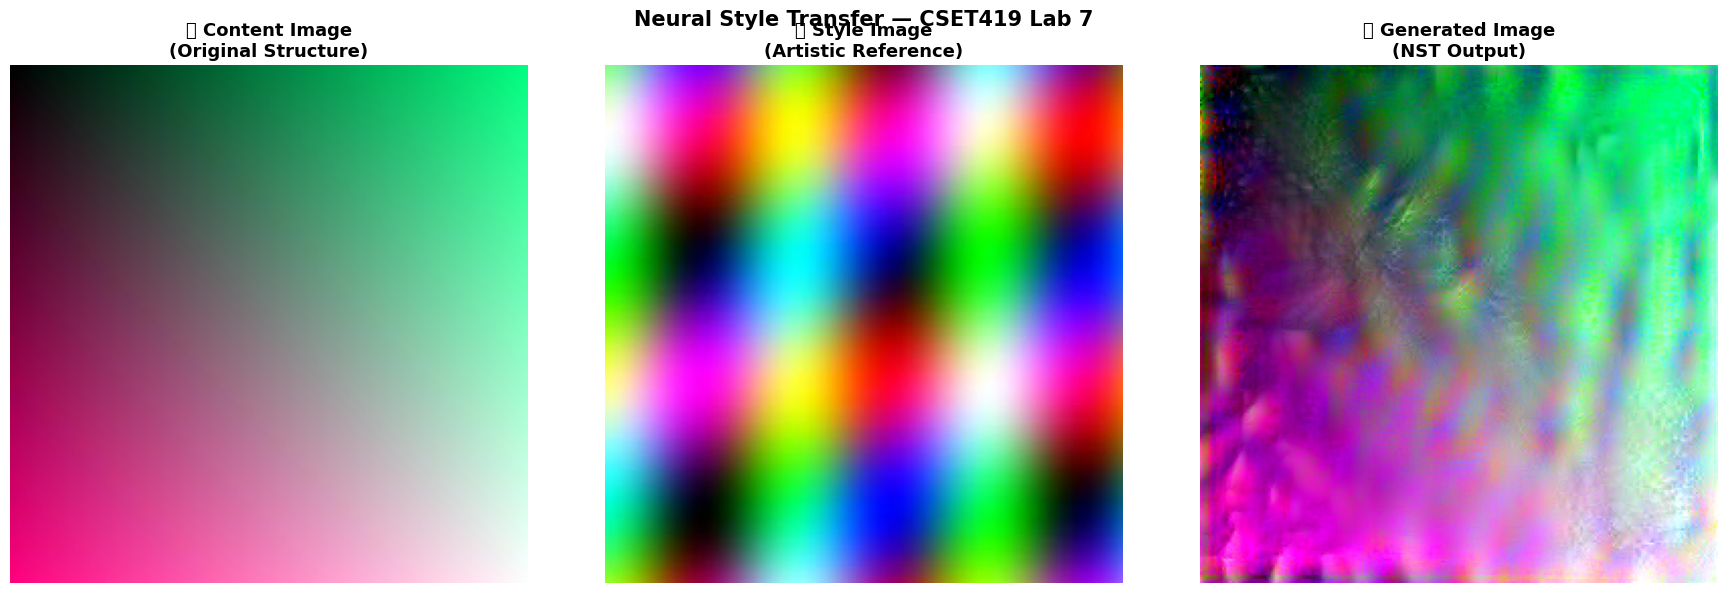

✅ Comparison figure saved → nst_outputs/comparison.png


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

images = [
    (content_img, '🏞️ Content Image\n(Original Structure)'),
    (style_img,   '🎨 Style Image\n(Artistic Reference)'),
    (generated,   '✨ Generated Image\n(NST Output)'),
]

for ax, (tensor, title) in zip(axes, images):
    ax.imshow(tensor_to_image(tensor))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Neural Style Transfer — CSET419 Lab 7', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('nst_outputs/comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison figure saved → nst_outputs/comparison.png')

## ✅ Cell 22 — Plot Loss Curves
These curves show how each loss component decreased over time, confirming the optimisation worked correctly.

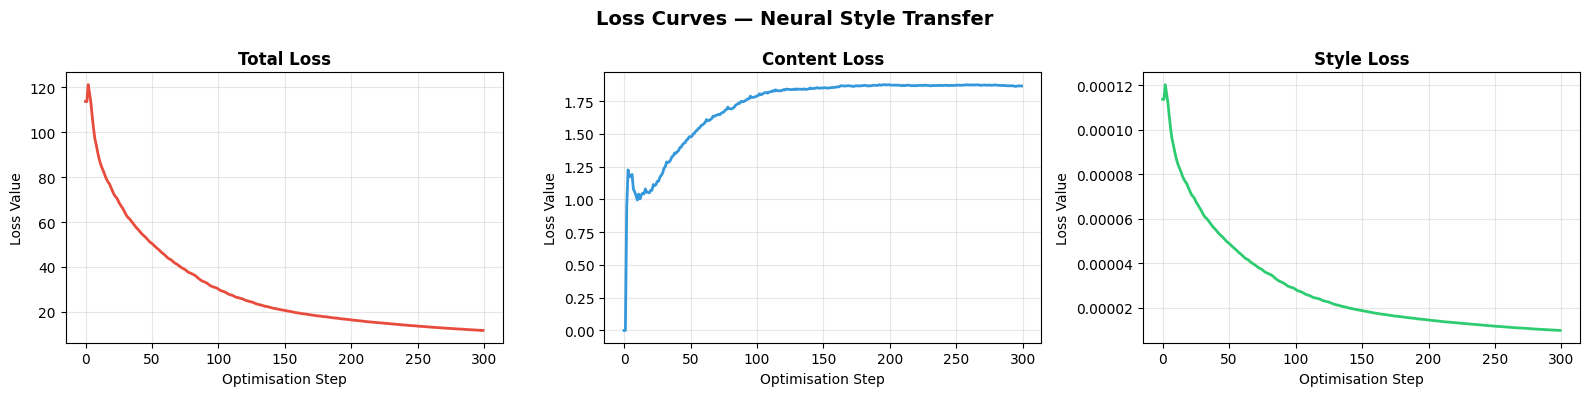

✅ Loss curves saved → nst_outputs/loss_curves.png


In [32]:
steps = range(len(loss_history['total']))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

configs = [
    ('total',   'Total Loss',   '#E74C3C'),
    ('content', 'Content Loss', '#3498DB'),
    ('style',   'Style Loss',   '#2ECC71'),
]

for ax, (key, title, color) in zip(axes, configs):
    ax.plot(steps, loss_history[key], color=color, linewidth=2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Optimisation Step')
    ax.set_ylabel('Loss Value')
    ax.grid(True, alpha=0.3)

plt.suptitle('Loss Curves — Neural Style Transfer', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nst_outputs/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Loss curves saved → nst_outputs/loss_curves.png')

## ✅ Cell 23 — Show Intermediate Progress
We saved the image every 50 steps. Let's display how it evolved from content → stylised output.

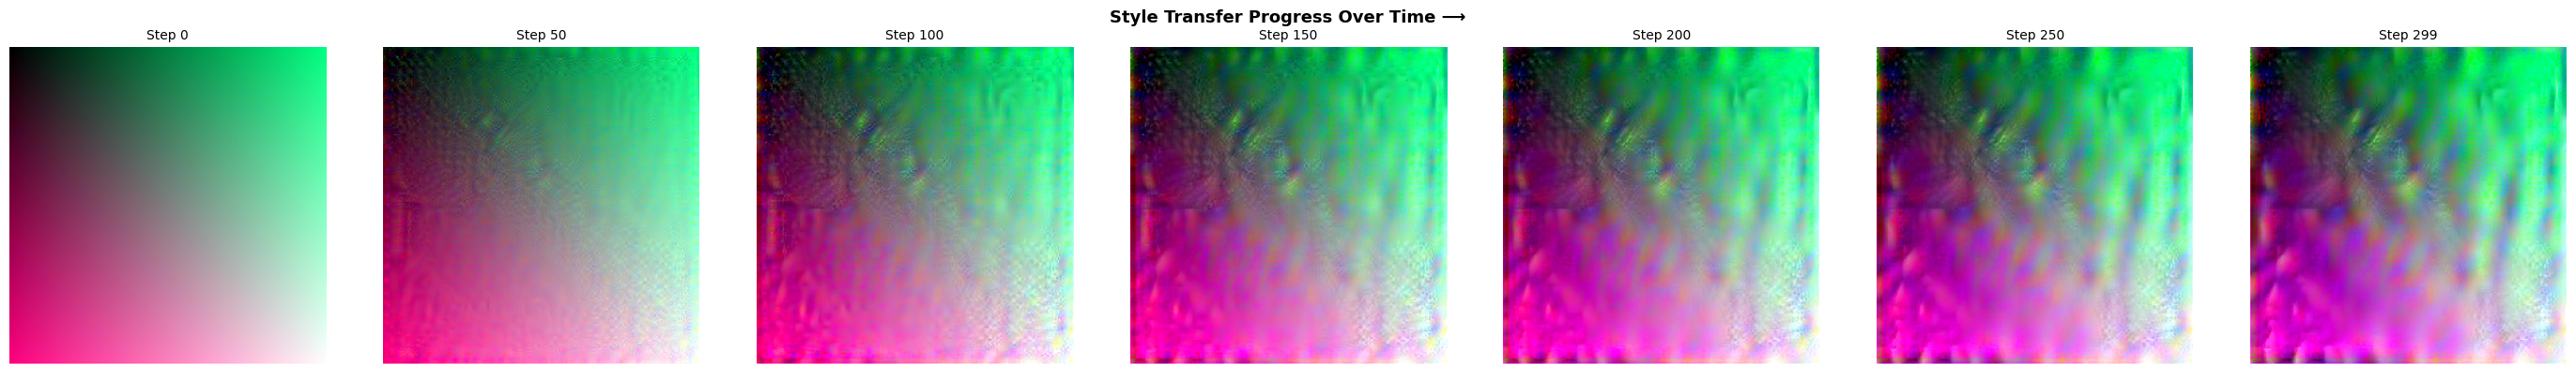

✅ Progress figure saved → nst_outputs/progress.png


In [33]:
# Find all saved step images
step_files = sorted([
    f for f in os.listdir('nst_outputs') if f.startswith('step_')
])

n = len(step_files)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]

for ax, fname in zip(axes, step_files):
    step_num = fname.replace('step_', '').replace('.png', '')
    ax.imshow(Image.open(f'nst_outputs/{fname}'))
    ax.set_title(f'Step {int(step_num)}', fontsize=10)
    ax.axis('off')

plt.suptitle('Style Transfer Progress Over Time ⟶', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nst_outputs/progress.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Progress figure saved → nst_outputs/progress.png')

## ✅ Cell 24 — List All Output Files

In [34]:
print('📂 Files saved in nst_outputs/')
print('-' * 40)
for f in sorted(os.listdir('nst_outputs')):
    size_kb = os.path.getsize(f'nst_outputs/{f}') // 1024
    print(f'   {f:<35}  {size_kb:>5} KB')
print()
print('🎉 Lab 7 Complete!')

📂 Files saved in nst_outputs/
----------------------------------------
   comparison.png                         452 KB
   final_output.png                       124 KB
   loss_curves.png                         97 KB
   progress.png                          1766 KB
   step_0000.png                           19 KB
   step_0050.png                          101 KB
   step_0100.png                          115 KB
   step_0150.png                          118 KB
   step_0200.png                          119 KB
   step_0250.png                          121 KB
   step_0299.png                          124 KB

🎉 Lab 7 Complete!


---
## 📋 Summary of All Cells

| Cell | What it does |
|------|--------------|
| 1 | Install libraries |
| 2 | Import libraries |
| 3 | Set GPU/CPU device |
| 4 | Auto-download sample images |
| 5 | Set image file paths |
| 6 | Preview input images |
| 7 | Image loader function |
| 8 | Tensor-to-image converter |
| 9 | Load content & style images |
| 10 | Define VGG19 layer names |
| 11 | Build frozen VGG19 feature extractor |
| 12 | Extract fixed feature maps |
| 13 | Content loss function |
| 14 | Gram matrix function |
| 15 | Style loss function |
| 16 | Total loss function |
| 17 | Initialise generated image |
| 18 | Set up L-BFGS optimiser |
| 19 | **Main optimisation loop** |
| 20 | Save final output image |
| 21 | Display 3 images side by side |
| 22 | Plot loss curves |
| 23 | Show optimisation progress |
| 24 | List all output files |

---
> **CSET419 — Lab 7 | Neural Style Transfer using VGG19**

In [35]:
import shutil

# Zip the entire nst_outputs folder
shutil.make_archive('NST_Results', 'zip', 'nst_outputs')

# Download the zip file
from google.colab import files
files.download('NST_Results.zip')
print('✅ Download started!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!
